# Photon-mosaic: a pipeline API for Calcium Imaging

This notebook demonstrates how to use photon-mosaic framework for use with calcium imaging data. We'll show how to:
- Load imaging data from TIFF files
- Explore and visualize the data
- Cache data for efficient processing
- Run Suite2P extraction on the imaging data

The core API is based on the SpikeInterface framework, which is widely used for extracellular electrophysiology data analysis. Photon-mosaic extends those concepts to calcium imaging workflows.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

import photon_mosaic as pm
import photon_mosaic.preprocessing as pmpre
import photon_mosaic.extractors as pme
import photon_mosaic.widgets as pmw
import photon_mosaic.segmentation as pms
%matplotlib widget

## Load Imaging Data

First, we'll load a TIFF file containing calcium imaging data. The `read_scan_image_tiff` function allows us to specify the channel and plane we want to extract.

In [2]:
# base_folder = Path("path-to-base-folder")
base_folder = Path("C:/Users/ariellel/data")

imaging = pme.read_tiff_imaging(file_path=base_folder / "spont_00001.tif", sampling_frequency=30)

C:\Users\ariellel\repos\photon-mosaic\src\photon_mosaic\extractors\roiextractors.py:19: UserWarning: memmap of TIFF file could not be established due to the following error: image data are not memory-mappable. Reading entire matrix into memory. Consider using the ScanImageTiffSinglePlaneImagingExtractor or ScanImageTiffMultiPlaneImagingExtractor for lazy data access.
  roi_extractor = self.roiextractor_imaging_class(**kwargs)


## Inspect the Imaging Object

The imaging object provides a summary of the loaded data, similar to how SpikeInterface recording objects work.

In [3]:
imaging

TiffImaging (ROIExtractors) (TiffImaging):
30.0Hz - 1 segments - 512 rows x 512 columns  - 1.1min - int16 dtype - 1000.0MiB

## Access Imaging Data

The imaging object supports lazy loading, allowing you to access specific frame ranges without loading the entire dataset into memory. This is particularly useful for large imaging sessions.

In [4]:
print(f"Number of frames {imaging.get_num_frames()}")
print(f"Image shape {imaging.image_shape}")
video_snippet = imaging.get_series(start_frame=0, end_frame=40) # demonstrating lazy access
print(f"Video snippet shape {video_snippet.shape}")

Number of frames 2000
Image shape [512 512]
Video snippet shape (40, 512, 512)


## Visualize the Average Image

We can compute and display the average image across a subset of chunks to get a sense of the field of view and visible structures.

2000

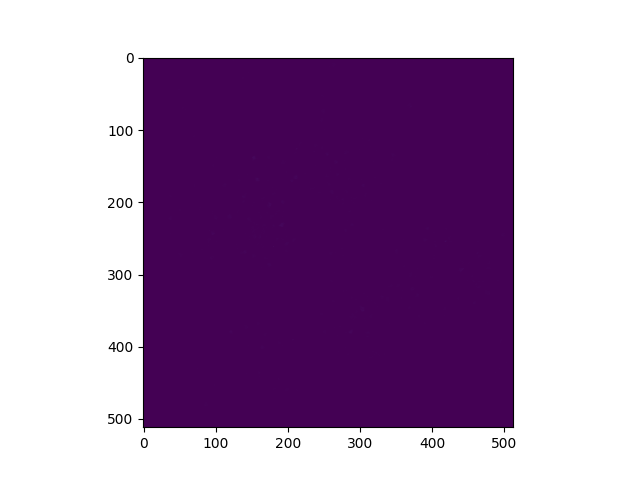

In [5]:
avg_image = imaging.get_average_image()
plt.figure()
plt.imshow(avg_image, vmax=8185)
imaging.get_num_frames()

## Run Suite2P Registration

Suite2P registration is a two-step process:

1. **Compute Motion**: First, we compute the motion correction across the entire recording. This step analyzes all frames to determine how much the tissue moved at each time point.
2. **Apply Correction**: Then, we create a corrected imaging object that applies the motion correction on-the-fly when you access frames.

This two-step approach ensures that you get consistent results regardless of how you slice the data.

In [6]:
# Step 1: Compute motion for the entire recording
# This step processes all frames once to determine displacement information
motion = pmpre.compute_motion_suite2p(imaging, reference_frames=150, batch_size=500)
print(f"Motion computed for {motion.num_segments} segment(s)")

# Step 2: Create motion-corrected imaging object
# This applies the correction on-the-fly when frames are accessed
registered = pmpre.RegisterSuite2PImaging(imaging, motion)

# Test it out - these should give consistent results
registered_subset = registered.get_series(200, 250)
print(f"Registered subset shape: {registered_subset.shape}")

Motion computed for 1 segment(s)
Registered subset shape: (50, 512, 512)


## Visualize Registered Data

Now let's visualize the motion-corrected imaging data:

In [8]:
import numpy as np
# Get the same frames two different ways
frames_direct = registered.get_series(200, 250)
frames_from_larger = registered.get_series(100, 300)[100:150]

# These should be identical
print(f"Frames are identical: {np.allclose(frames_direct, frames_from_larger)}")
print(f"Max difference: {np.max(np.abs(frames_direct - frames_from_larger))}")

Frames are identical: True
Max difference: 0.0


## Verify Consistency

One of the key benefits of the two-step approach is that you get the same corrected frames regardless of how you slice the data. Let's verify this:

In [9]:
pmw.plot_imaging_series(registered, backend="ipywidgets")